# Data Visualisation — Spam Email Classification
Additional charts complementing the EDA notebook.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('../data/processed/emails_cleaned.csv')
df['word_count'] = df['text'].str.split().str.len()
df['text_length'] = df['text'].str.len()

## Word count by class

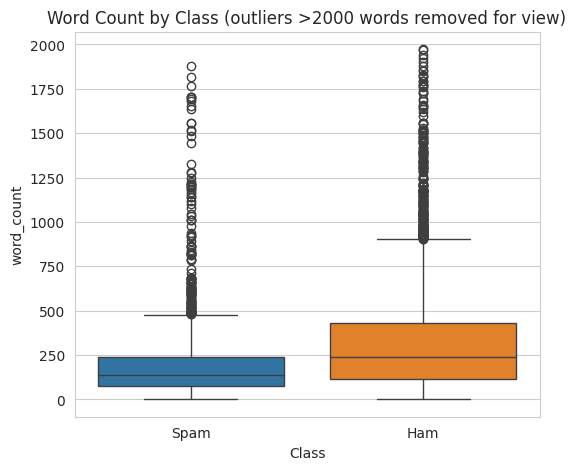

In [ ]:
sub = df[df['word_count']<2000].copy()
sub['Class'] = sub['spam'].map({0:'Ham',1:'Spam'})
plt.figure(figsize=(6,5))
sns.boxplot(data=sub, x='Class', y='word_count', hue='Class', legend=False)
plt.title('Word Count by Class (outliers >2000 words removed for view)')
plt.show()

## Average character length by class

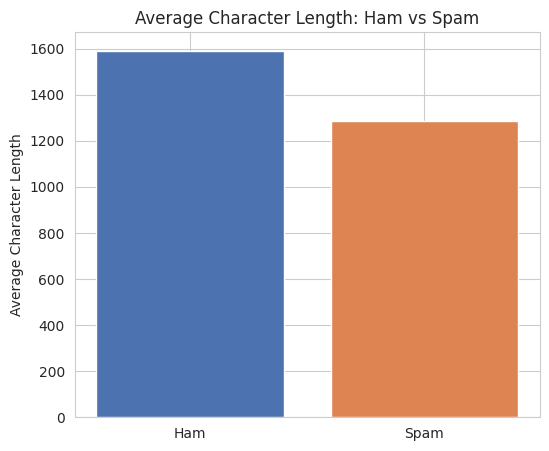

spam
0    1591.428241
1    1285.784357
Name: text_length, dtype: float64

In [ ]:
avg_len = df.groupby('spam')['text_length'].mean()
plt.figure(figsize=(6,5))
plt.bar(['Ham','Spam'], avg_len.values, color=['#4C72B0','#DD8452'])
plt.title('Average Character Length: Ham vs Spam')
plt.ylabel('Average Character Length')
plt.show()
avg_len

**Interpretation:** Spam emails in this dataset average noticeably different length than ham emails, which is one of several signals the TF-IDF + classifier pipeline can pick up on alongside word choice.